<a href="https://colab.research.google.com/github/alansiny/INTERSHIP-AI-ML/blob/main/NLP_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd

In [17]:
df=pd.read_csv('/content/final_dataset.csv')

In [18]:
df.head()

,text,emotion
0,i feel rather funny ending with so many dupes ...,fun
1,i feel surprised by the result,surprise
2,i am officially feeling festive,neutral
3,i suddenly found myself standing before this w...,surprise
4,i look at the meager pile of food i purchased ...,enthusiasm


In [19]:
df['text'] = df['text'].str.lower()

In [20]:
df['text'].head()

,text
0,i feel rather funny ending with so many dupes ...
1,i feel surprised by the result
2,i am officially feeling festive
3,i suddenly found myself standing before this w...
4,i look at the meager pile of food i purchased ...


In [21]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize,sent_tokenize
import nltk

In [22]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [23]:
stop_words=set(stopwords.words('english'))

lematiser=WordNetLemmatizer()

In [24]:
def process_text(text):
  word_tokens=word_tokenize(text)
  filter_tokens=[word for word in word_tokens if word.lower() not in stop_words]
  lematized_tokens=[lematiser.lemmatize(word.lower()) for word in filter_tokens]

  return {
      'orginal_text':text,
      'word_tokens':word_tokens,
      'filter_tokens':filter_tokens,
      'lematized_tokens':lematized_tokens

  }

In [25]:
result=df['text'].apply(process_text)
processed_df=pd.DataFrame(result.tolist())
print(processed_df.head())



                                        orginal_text  \
0  i feel rather funny ending with so many dupes ...   
1                     i feel surprised by the result   
2                    i am officially feeling festive   
3  i suddenly found myself standing before this w...   
4  i look at the meager pile of food i purchased ...   

                                         word_tokens  \
0  [i, feel, rather, funny, ending, with, so, man...   
1              [i, feel, surprised, by, the, result]   
2              [i, am, officially, feeling, festive]   
3  [i, suddenly, found, myself, standing, before,...   
4  [i, look, at, the, meager, pile, of, food, i, ...   

                                       filter_tokens  \
0  [feel, rather, funny, ending, many, dupes, alw...   
1                          [feel, surprised, result]   
2                     [officially, feeling, festive]   
3  [suddenly, found, standing, woman, dressed, li...   
4  [look, meager, pile, food, purchased, week,

In [26]:
print('\n before stopword removal')
df['text']


 before stopword removal


,text
0,i feel rather funny ending with so many dupes ...
1,i feel surprised by the result
2,i am officially feeling festive
3,i suddenly found myself standing before this w...
4,i look at the meager pile of food i purchased ...
...,...
106350,i used to feel strongly about how much i hated...
106351,i feel like i just got a spirit booster this r...
106352,i could come up with is that i was really feel...
106353,i find it really it helps to have an outfit of...


In [27]:
import pandas as pd
import nltk
from nltk.stem import WordNetLemmatizer,PorterStemmer
from nltk.tokenize import word_tokenize

In [28]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [29]:
lematiser=WordNetLemmatizer()

In [30]:
stemmer = PorterStemmer()

def lemmatize_text(text):
    tokens = word_tokenize(str(text))
    return ' '.join([lemmatizer.lemmatize(word) for word in tokens])

def stem_text(text):
    tokens = word_tokenize(str(text))
    return ' '.join([stemmer.stem(word) for word in tokens])

In [31]:
from nltk.stem import WordNetLemmatizer, PorterStemmer

lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
df['lemmatized_text'] = df['text'].apply(lemmatize_text)
df['stemmed_text'] = df['text'].apply(stem_text)

In [32]:
print(df[['text', 'stemmed_text']].head(10))

                                                text  \
0  i feel rather funny ending with so many dupes ...   
1                     i feel surprised by the result   
2                    i am officially feeling festive   
3  i suddenly found myself standing before this w...   
4  i look at the meager pile of food i purchased ...   
5  i, for one, am thrilled that christ works outs...   
6  i hate that she has the power to make me feel ...   
7                            i feel like i missed it   
8  i have personally experienced this gut wrenchi...   
9  i hate feeling that people see me as ugly but ...   

                                        stemmed_text  
0  i feel rather funni end with so mani dupe whil...  
1                       i feel surpris by the result  
2                            i am offici feel festiv  
3  i suddenli found myself stand befor thi woman ...  
4  i look at the meager pile of food i purchas fo...  
5  i , for one , am thrill that christ work outsi... 

In [33]:
df[['text', 'lemmatized_text', 'stemmed_text']].head(10)

,text,lemmatized_text,stemmed_text
0,i feel rather funny ending with so many dupes ...,i feel rather funny ending with so many dupe w...,i feel rather funni end with so mani dupe whil...
1,i feel surprised by the result,i feel surprised by the result,i feel surpris by the result
2,i am officially feeling festive,i am officially feeling festive,i am offici feel festiv
3,i suddenly found myself standing before this w...,i suddenly found myself standing before this w...,i suddenli found myself stand befor thi woman ...
4,i look at the meager pile of food i purchased ...,i look at the meager pile of food i purchased ...,i look at the meager pile of food i purchas fo...
5,"i, for one, am thrilled that christ works outs...","i , for one , am thrilled that christ work out...","i , for one , am thrill that christ work outsi..."
6,i hate that she has the power to make me feel ...,i hate that she ha the power to make me feel s...,i hate that she ha the power to make me feel s...
7,i feel like i missed it,i feel like i missed it,i feel like i miss it
8,i have personally experienced this gut wrenchi...,i have personally experienced this gut wrenchi...,i have person experienc thi gut wrench feel an...
9,i hate feeling that people see me as ugly but ...,i hate feeling that people see me a ugly but i...,i hate feel that peopl see me as ugli but i kn...


In [34]:
from sklearn.feature_extraction.text import CountVectorizer

# Create CountVectorizer object
cv = CountVectorizer()

# Fit and transform text data
X = cv.fit_transform(df['text'])

# Vocabulary
print("Vocabulary:")
print(cv.vocabulary_)

# Feature names
print("\nFeature Names:")
print(cv.get_feature_names_out())

# Matrix
print("\nCount Matrix:")
print(X.toarray())

# Shape
print("\nShape:")
print(X.shape)

Vocabulary:
{'feel': 13807, 'rather': 31096, 'funny': 15178, 'ending': 12414, 'with': 42802, 'so': 35471, 'many': 23501, 'dupes': 11654, 'while': 42472, 'always': 1684, 'prefer': 29812, 'originals': 27377, 'surprised': 37438, 'by': 5711, 'the': 38469, 'result': 32134, 'am': 1697, 'officially': 26905, 'feeling': 13820, 'festive': 13923, 'suddenly': 37130, 'found': 14738, 'myself': 25566, 'standing': 36355, 'before': 3784, 'this': 38632, 'woman': 42900, 'dressed': 11427, 'like': 22330, 'priestess': 29993, 'white': 42516, 'robes': 32553, 'and': 1884, 'egyptian': 12041, 'jewellery': 20368, 'long': 22714, 'black': 4329, 'hair': 16919, 'realized': 31225, 'that': 38449, 'was': 42064, 'amorous': 1807, 'passionate': 28163, 'noticed': 26495, 'to': 39043, 'my': 25541, 'surprise': 37437, 'breath': 5118, 'green': 16460, 'breathing': 5123, 'out': 27484, 'clouds': 7370, 'of': 26872, 'energy': 12452, 'look': 22745, 'at': 2726, 'meager': 23920, 'pile': 28922, 'food': 14553, 'purchased': 30551, 'for': 1

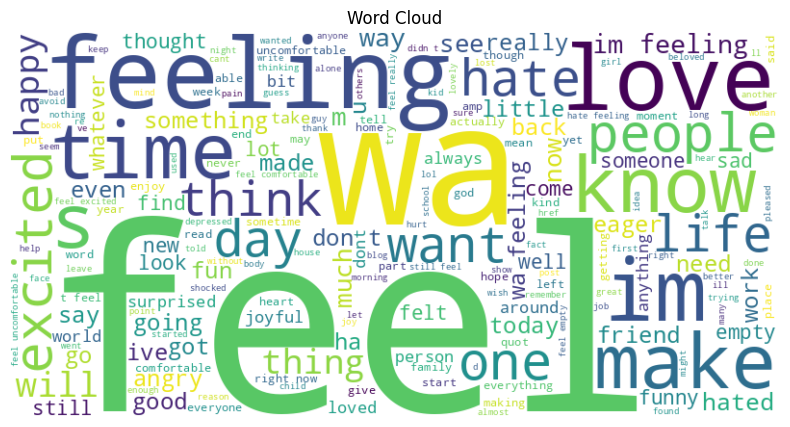

In [35]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all text into one string
text = ' '.join(df['lemmatized_text'])

# Generate Word Cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

# Display Word Cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud')
plt.show()